In [20]:
# 1. Bibliotheken importieren
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime
import os
import holidays

# Ordner zum Speichern erstellen
os.makedirs("Graphen Data Exploration", exist_ok=True)

# Anzeigeoptionen
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# 2. Daten laden
df = pd.read_csv("merged.csv", parse_dates=["DateTime"])

start_date = df["DateTime"].min().date()
end_date = df["DateTime"].max().date()

# Beispielkoordinaten: Wien
latitude = 48.2082
longitude = 16.3738

# Wetterdaten via API
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "hourly": "temperature_2m,shortwave_radiation,wind_speed_10m",
    "timezone": "auto"
}
response = requests.get(url, params=params)
data = response.json()

# Wetter-DataFrame
hourly_data = data.get("hourly", {})
weather = pd.DataFrame(hourly_data)
if "time" in weather.columns:
    weather["time"] = pd.to_datetime(weather["time"])

# Mergen
df = df.sort_values("DateTime")
weather = weather.sort_values("time")
df = pd.merge_asof(df, weather, left_on="DateTime", right_on="time", direction="backward")
df = df.drop(columns=["time"])


In [45]:
# 3. Übersicht
print(df.head())
print(df.info())
print(df.describe())
print(df.columns)

                     Actual_Solar  Actual_Wind Onshore  DayAhead_Solar  \
DateTime                                                                 
2014-12-01 23:00:00           NaN                  NaN             NaN   
2014-12-01 23:15:00           NaN                  NaN             NaN   
2014-12-01 23:30:00           NaN                  NaN             NaN   
2014-12-01 23:45:00           NaN                  NaN             NaN   
2014-12-02 00:00:00           NaN                  NaN             NaN   

                     DayAhead_Wind Onshore  Load_Actual  Load_DayAhead  \
DateTime                                                                 
2014-12-01 23:00:00                    NaN       6493.6            NaN   
2014-12-01 23:15:00                    NaN       6350.4            NaN   
2014-12-01 23:30:00                    NaN       6494.0            NaN   
2014-12-01 23:45:00                    NaN       6463.2            NaN   
2014-12-02 00:00:00                  

In [22]:
# 4. Fehlende Werte
missing = df.isnull().sum()
print("Fehlende Werte je Spalte:")
print(missing[missing > 0])

Fehlende Werte je Spalte:
Actual_Solar             134471
Actual_Wind Onshore      134471
DayAhead_Solar           134300
DayAhead_Wind Onshore    134300
Load_Actual                 166
Load_DayAhead               864
Price_DayAhead             7935
dtype: int64


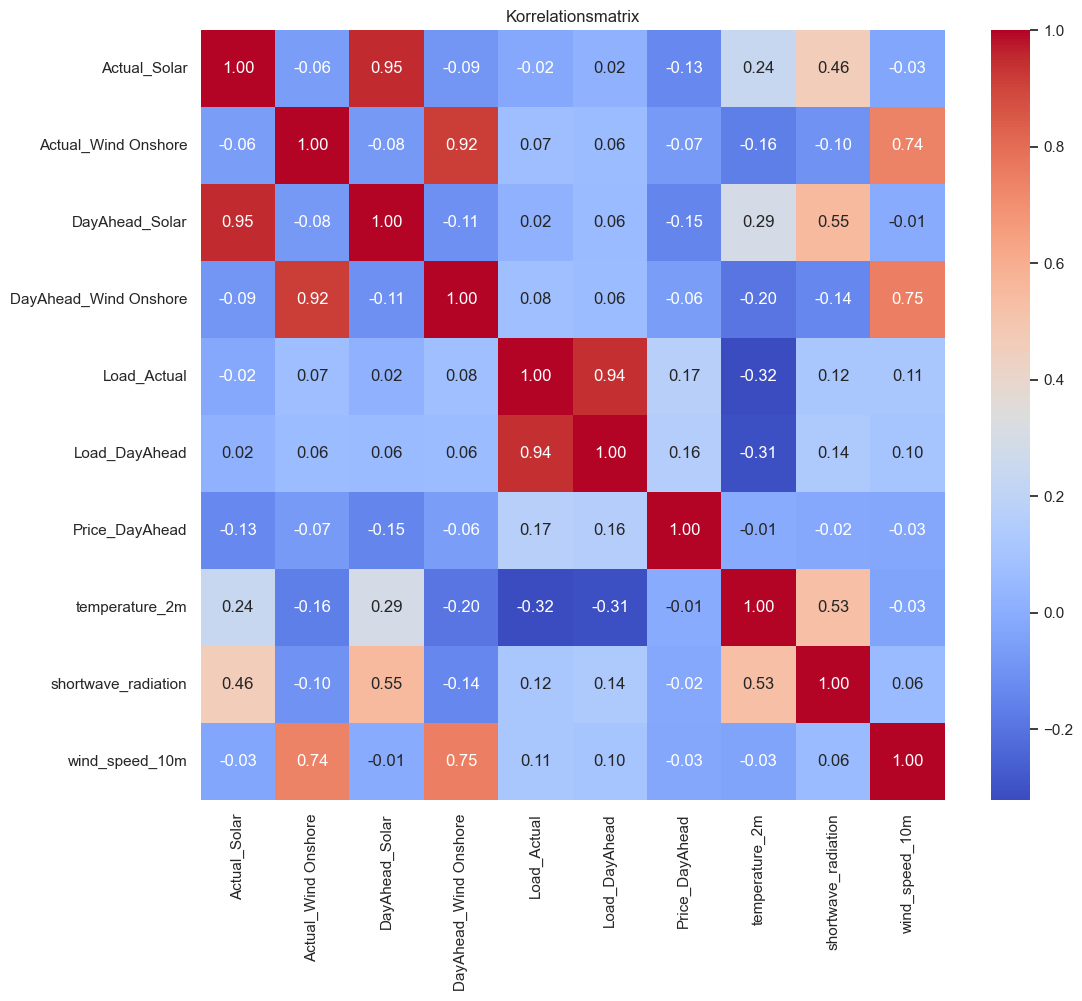

In [23]:
# 5. Korrelationen
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korrelationsmatrix")

plt.savefig('Graphen Data Exploration/Korrelationsmatrix.png', bbox_inches='tight')
plt.show()
plt.close()

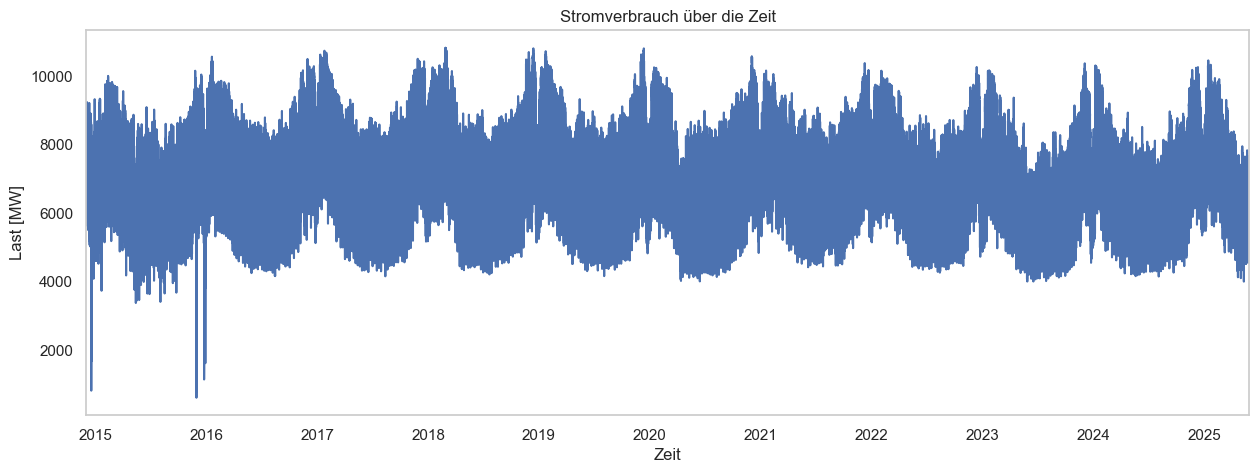

In [24]:
# 6. Zeitreihe: Stromverbrauch
df.set_index("DateTime", inplace=True)
df.index = pd.to_datetime(df.index)
df["Load_Actual"].plot(figsize=(15, 5), title="Stromverbrauch über die Zeit")
plt.ylabel("Last [MW]")
plt.xlabel("Zeit")
plt.grid()

plt.savefig('Graphen Data Exploration/Stromverbrauch über die Zeit.png', bbox_inches='tight')
plt.show()
plt.close()

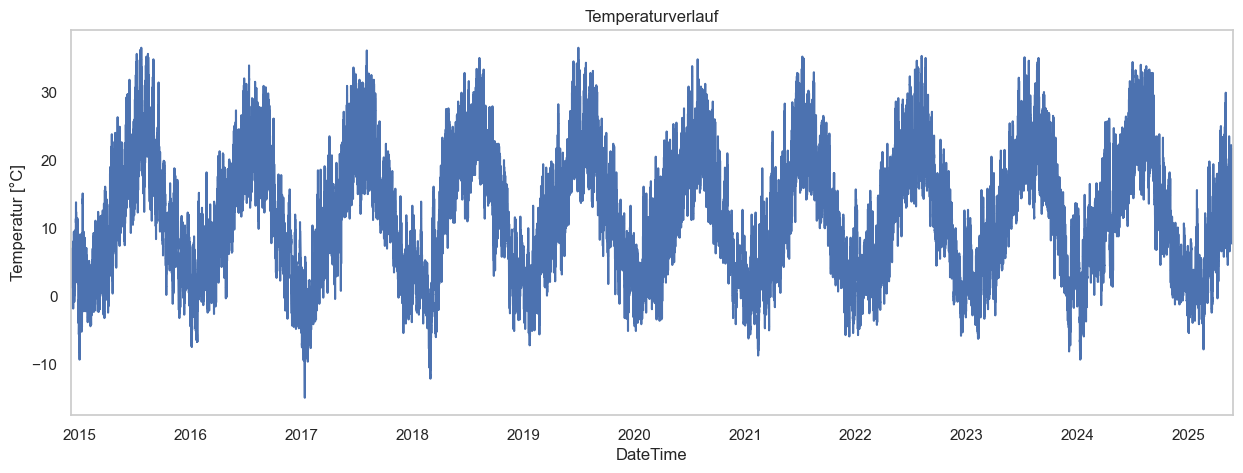

In [25]:
# 7. Temperaturverlauf
df["temperature_2m"].plot(figsize=(15, 5), title="Temperaturverlauf")
plt.ylabel("Temperatur [°C]")
plt.grid()

plt.savefig('Graphen Data Exploration/Temperaturverlauf', bbox_inches='tight')
plt.show()
plt.close()

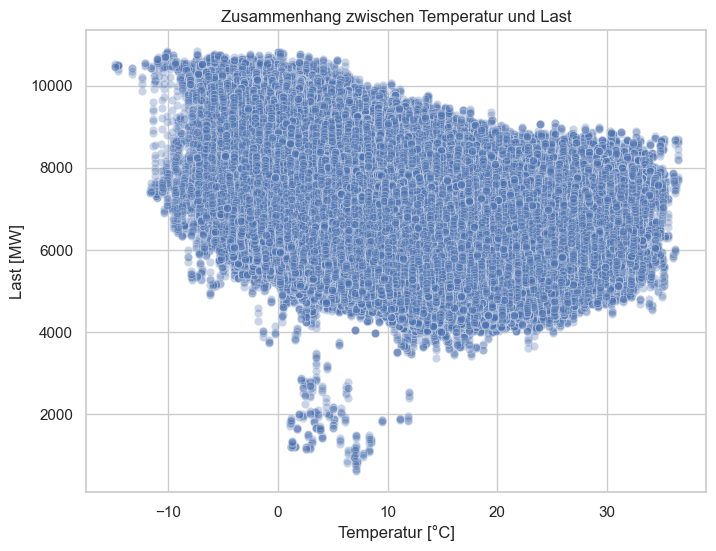

In [26]:
# 8. Last vs Temperatur
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature_2m", y="Load_Actual", alpha=0.3)
plt.title("Zusammenhang zwischen Temperatur und Last")
plt.xlabel("Temperatur [°C]")
plt.ylabel("Last [MW]")

plt.savefig('Graphen Data Exploration/Zusammenhang zwischen Temperatur und Last', bbox_inches='tight')
plt.show()
plt.close()

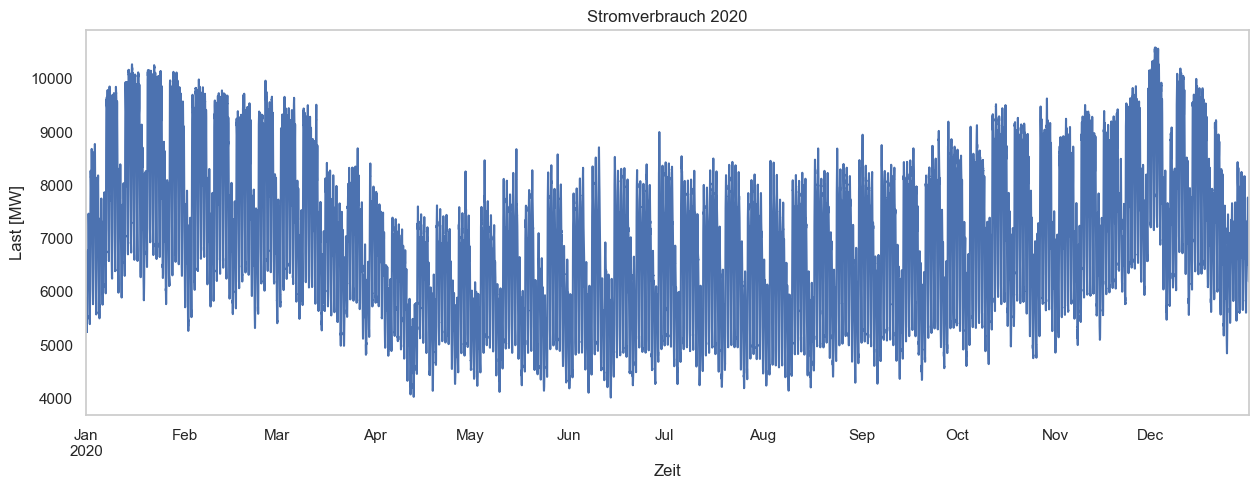

In [27]:
# 9. Stromverbrauch 2020
df_2020 = df[df.index.year == 2020]
df_2020["Load_Actual"].plot(figsize=(15, 5), title="Stromverbrauch 2020")
plt.ylabel("Last [MW]")
plt.xlabel("Zeit")
plt.grid()

plt.savefig('Graphen Data Exploration/Stromverbrauch 2020', bbox_inches='tight')
plt.show()
plt.close()

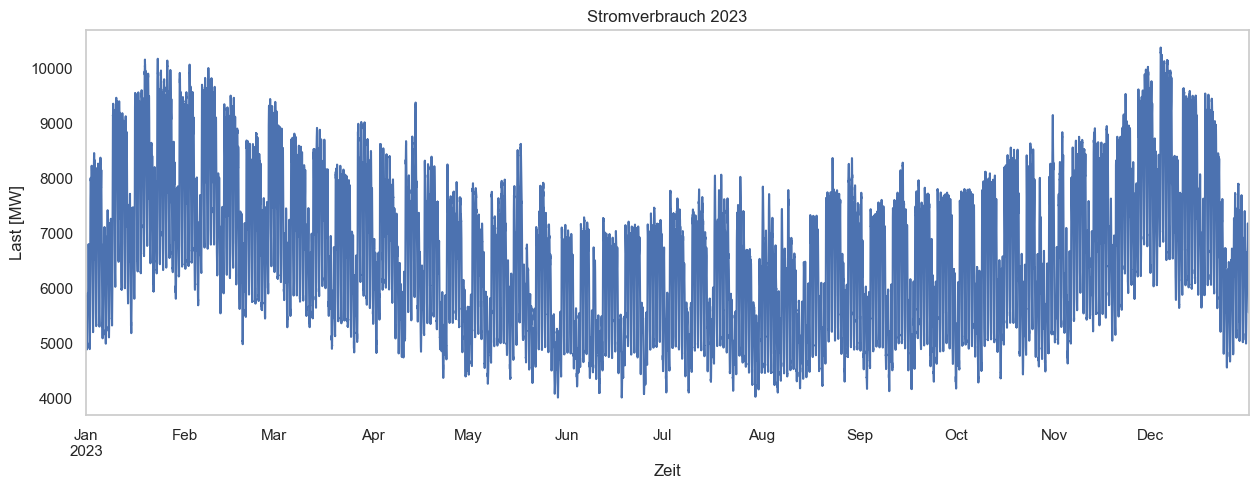

In [28]:
# 10. Stromverbrauch 2023
df_2023 = df[df.index.year == 2023]
df_2023["Load_Actual"].plot(figsize=(15, 5), title="Stromverbrauch 2023")
plt.ylabel("Last [MW]")
plt.xlabel("Zeit")
plt.grid()

plt.savefig('Graphen Data Exploration/Stromverbrauch 2023', bbox_inches='tight')
plt.show()
plt.close()

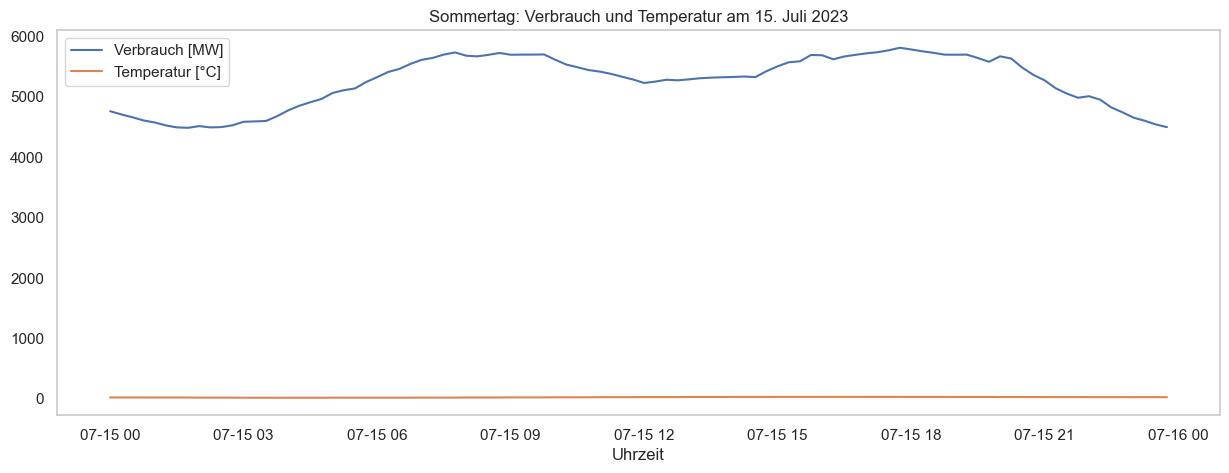

In [35]:
# 11. Sommertag: 15. Juli 2023
summer_day = df[df.index.date == pd.to_datetime("2023-07-15").date()]
plt.figure(figsize=(15, 5))
plt.plot(summer_day.index, summer_day["Load_Actual"], label="Verbrauch [MW]")
plt.plot(summer_day.index, summer_day["temperature_2m"], label="Temperatur [°C]")
plt.title("Sommertag: Verbrauch und Temperatur am 15. Juli 2023")
plt.xlabel("Uhrzeit")
plt.legend()
plt.grid()

plt.savefig('Graphen Data Exploration/Sommertag - Verbrauch und Temperatur am 15 Juli 2023', bbox_inches='tight')
plt.show()
plt.close()

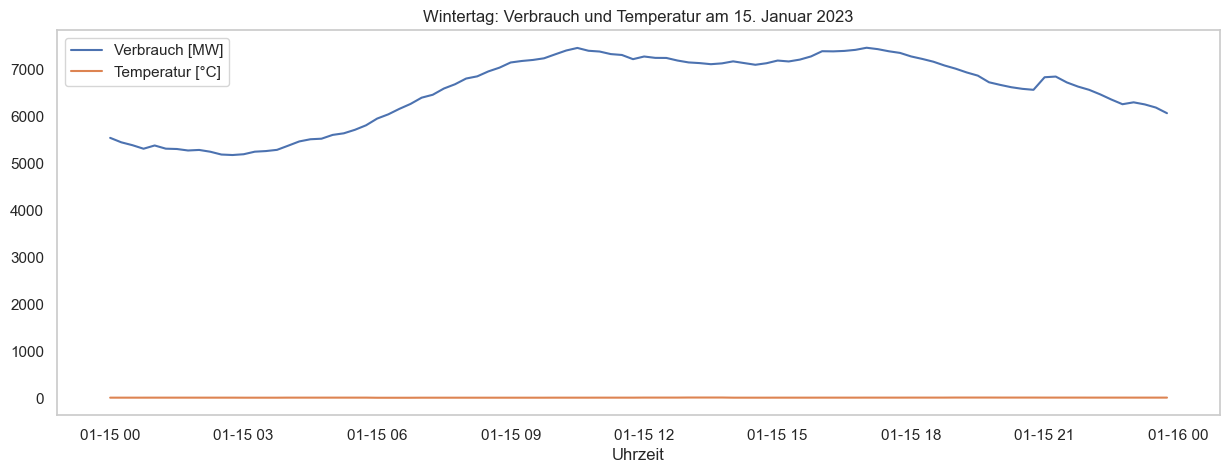

In [37]:
# 12. Wintertag: 15. Januar 2023
winter_day = df[df.index.date == pd.to_datetime("2023-01-15").date()]
plt.figure(figsize=(15, 5))
plt.plot(winter_day.index, winter_day["Load_Actual"], label="Verbrauch [MW]")
plt.plot(winter_day.index, winter_day["temperature_2m"], label="Temperatur [°C]")
plt.title("Wintertag: Verbrauch und Temperatur am 15. Januar 2023")
plt.xlabel("Uhrzeit")
plt.legend()
plt.grid()

plt.savefig('Graphen Data Exploration/Wintertag- Verbrauch und Temperatur am 15 Januar 2023', bbox_inches='tight')
plt.show()
plt.close()

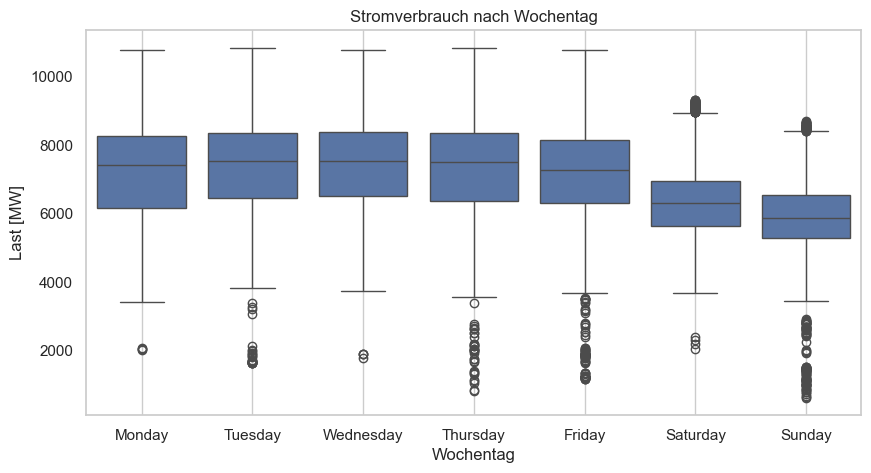

In [38]:
# 13. Verbrauch nach Wochentagen
df["weekday"] = df.index.day_name()
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="weekday", y="Load_Actual", order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.title("Stromverbrauch nach Wochentag")
plt.ylabel("Last [MW]")
plt.xlabel("Wochentag")
plt.grid()

plt.savefig('Graphen Data Exploration/Stromverbrauch nach Wochentag', bbox_inches='tight')
plt.show()
plt.close()

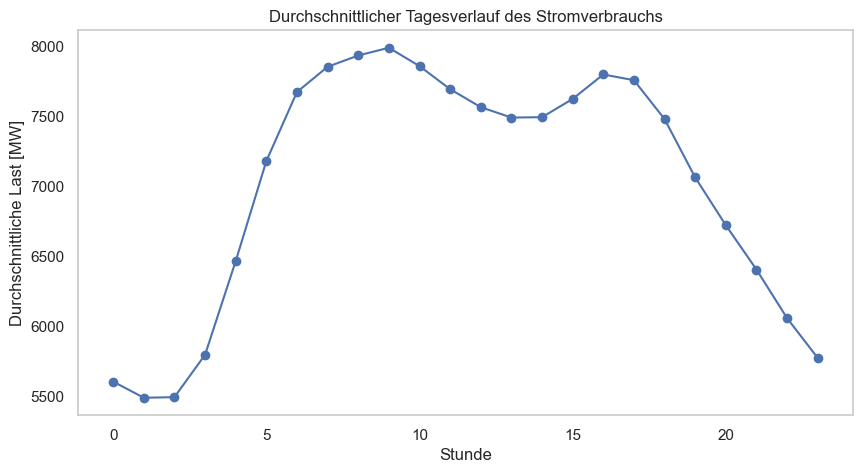

In [39]:
# 14. Durchschnittlicher Tagesverlauf
df["hour"] = df.index.hour
avg_profile = df.groupby("hour")["Load_Actual"].mean()
plt.figure(figsize=(10, 5))
avg_profile.plot(marker="o")
plt.title("Durchschnittlicher Tagesverlauf des Stromverbrauchs")
plt.xlabel("Stunde")
plt.ylabel("Durchschnittliche Last [MW]")
plt.grid()

plt.savefig('Graphen Data Exploration/Durchschnittlicher Tagesverlauf des Stromverbrauchs', bbox_inches='tight')
plt.show()
plt.close()

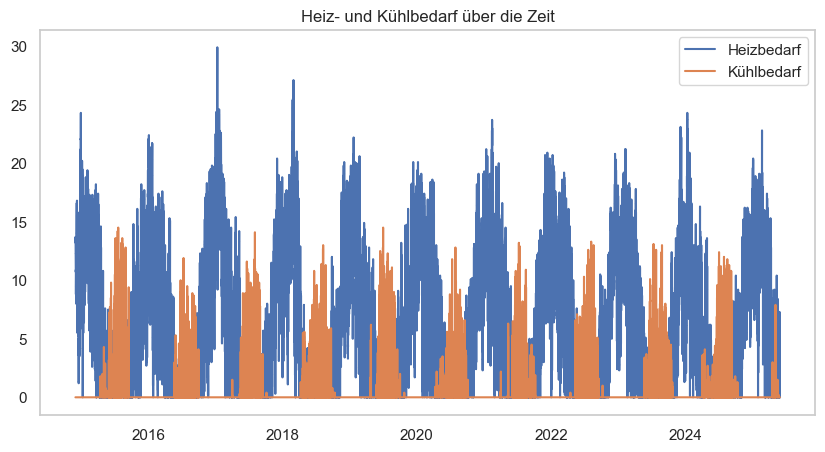

In [40]:
# 15. Heiz- und Kühlbedarf
df["heating_demand"] = df["temperature_2m"].apply(lambda t: max(0, 15 - t))
df["cooling_demand"] = df["temperature_2m"].apply(lambda t: max(0, t - 22))
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["heating_demand"], label="Heizbedarf")
plt.plot(df.index, df["cooling_demand"], label="Kühlbedarf")
plt.title("Heiz- und Kühlbedarf über die Zeit")
plt.legend()
plt.grid()

plt.savefig('Graphen Data Exploration/Heiz- und Kühlbedarf über die Zeit', bbox_inches='tight')
plt.show()
plt.close()

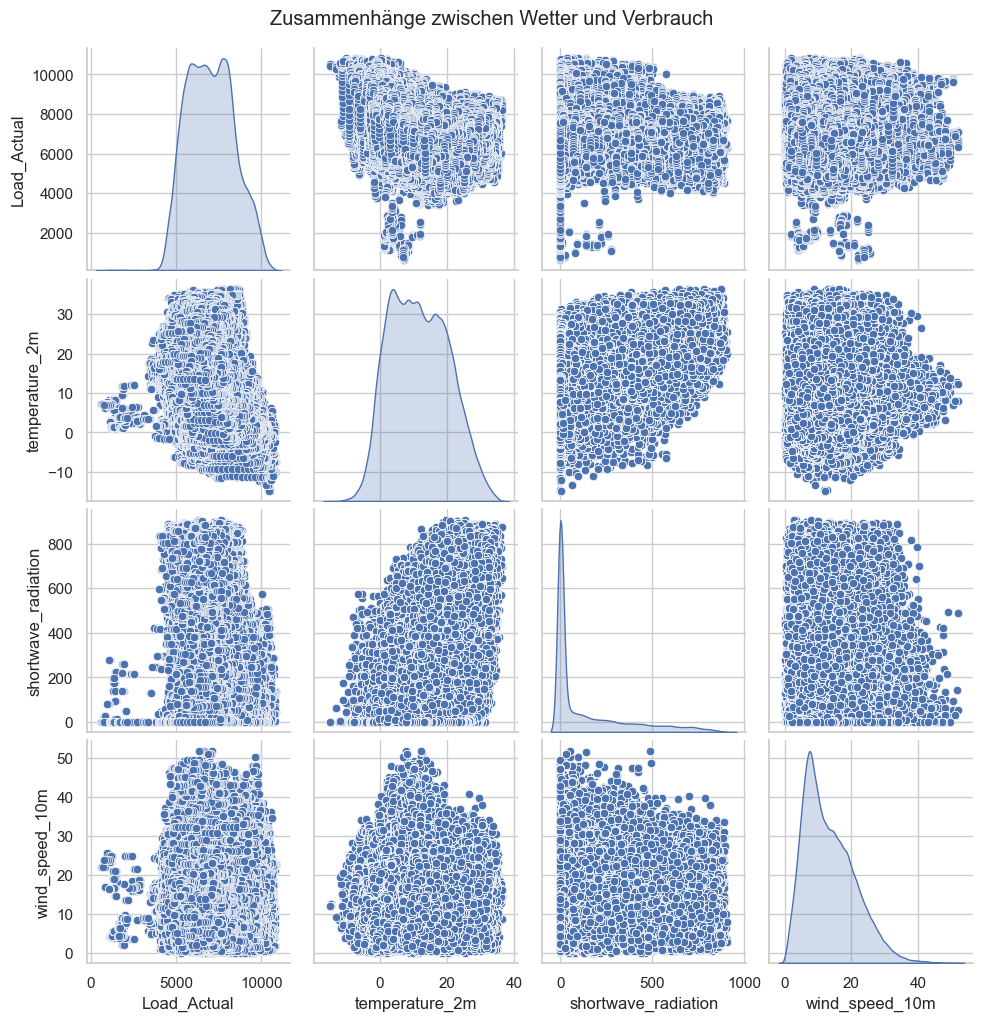

In [41]:
# 16. Pairplot
subset = df[["Load_Actual", "temperature_2m", "shortwave_radiation", "wind_speed_10m"]].dropna()
sns.pairplot(subset, diag_kind="kde")
plt.suptitle("Zusammenhänge zwischen Wetter und Verbrauch", y=1.02)

plt.savefig('Graphen Data Exploration/Zusammenhänge zwischen Wetter und Verbrauch', bbox_inches='tight')
plt.show()
plt.close()

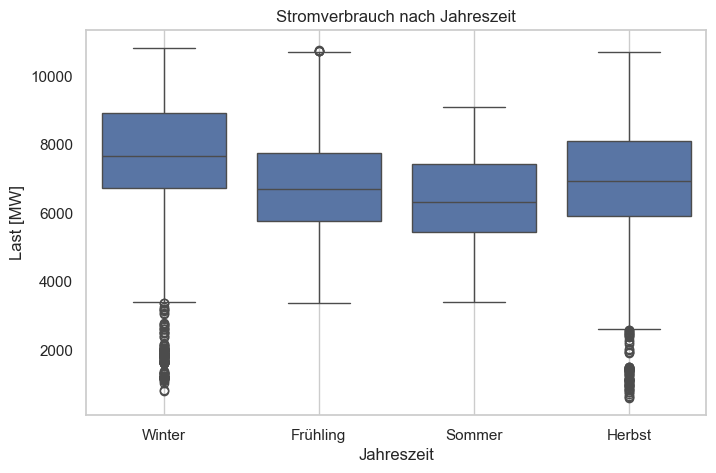

In [42]:
# 17. Verbrauch nach Jahreszeit
df["month"] = df.index.month
df["season"] = df["month"].map({12: "Winter", 1: "Winter", 2: "Winter",
                                 3: "Frühling", 4: "Frühling", 5: "Frühling",
                                 6: "Sommer", 7: "Sommer", 8: "Sommer",
                                 9: "Herbst", 10: "Herbst", 11: "Herbst"})
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="season", y="Load_Actual", order=["Winter", "Frühling", "Sommer", "Herbst"])
plt.title("Stromverbrauch nach Jahreszeit")
plt.xlabel("Jahreszeit")
plt.ylabel("Last [MW]")
plt.grid()

plt.savefig('Graphen Data Exploration/Stromverbrauch nach Jahreszeit', bbox_inches='tight')
plt.show()
plt.close()


<Figure size 1000x600 with 0 Axes>

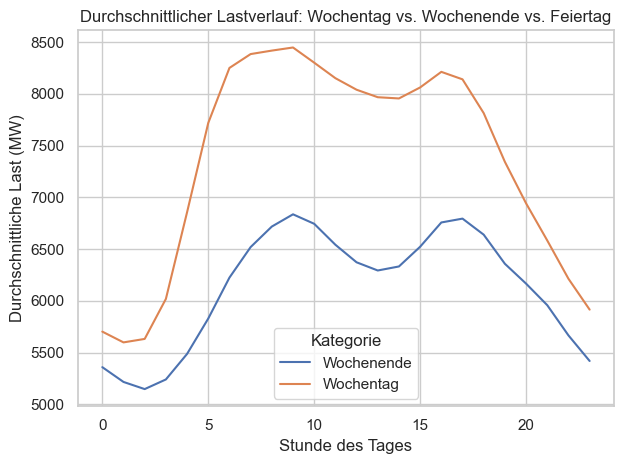

In [55]:
# Feiertags-Informationen für Österreich
at_holidays = holidays.CountryHoliday("AT")

# Zusätzliche Spalten
df["DateTime"] = df.index
df["Date"] = df["DateTime"].dt.date
df["Hour"] = df["DateTime"].dt.hour
df["Weekday"] = df["DateTime"].dt.weekday
df["IsWeekend"] = df["Weekday"] >= 5
df["IsHoliday"] = df["Date"].isin(at_holidays)
df["Category"] = "Wochentag"
df.loc[df["IsWeekend"], "Category"] = "Wochenende"
df.loc[df["IsHoliday"], "Category"] = "Feiertag"

# Durchschnittlicher Lastverlauf
grouped = df.groupby(["Hour", "Category"])["Load_Actual"].mean().unstack()

# Plotten
plt.figure(figsize=(10, 6))
grouped.plot()
plt.title("Durchschnittlicher Lastverlauf: Wochentag vs. Wochenende vs. Feiertag")
plt.xlabel("Stunde des Tages")
plt.ylabel("Durchschnittliche Last (MW)")
plt.grid(True)
plt.legend(title="Kategorie")
plt.tight_layout()

plt.savefig('Graphen Data Exploration/Stromverbrauch nach Jahreszeit', bbox_inches='tight')
plt.show()
plt.close()